In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import beta as beta_function
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
NUM_SCENARIOS = 50000
CONFIDENCE_LEVELS = [0.95, 0.99]
np.random.seed(42)
 
# Ratings (ordered from best to worst)
RATINGS = ['Aa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa-C', 'Default']
RATING_INDEX = {rating: i for i, rating in enumerate(RATINGS)}

In [3]:
#Steps 1 & 2: Uncorrelated and Correlated asset returns

In [4]:
def generate_correlated_returns(num_scenarios, cholesky_matrix, num_bonds=3):
    """
    Generate correlated asset returns using Cholesky decomposition.
    
    Args:
        num_scenarios: Number of MC scenarios (50,000)
        cholesky_matrix: 3x3 lower triangular Cholesky matrix
        num_bonds: Number of bonds (3)
    
    Returns:
        correlated_returns: (num_scenarios, num_bonds) array of correlated returns
    """
    # Step 1: Generate uncorrelated standard normal returns
    uncorrelated_returns = np.random.standard_normal((num_scenarios, num_bonds))
    
    # Step 2: Apply Cholesky matrix to induce correlation
    # Formula: correlated = uncorrelated @ cholesky.T
    correlated_returns = uncorrelated_returns @ cholesky_matrix.T
    
    return correlated_returns, uncorrelated_returns

In [5]:
#Step 3: Map Returns to Rating Scenarios Using Thresholds

In [6]:
 def map_returns_to_ratings(correlated_returns, rating_thresholds):
    """
    Map correlated asset returns to rating states using proper CreditMetrics thresholds.
    
    rating_thresholds[bond] contains:
        - "thresholds": np.array([...]) sorted ascending
        - "states":     list of rating labels, len = len(thresholds) + 1
    """
    num_scenarios, num_bonds = correlated_returns.shape
    rating_scenarios = {}

    for bond_idx, (bond_name, info) in enumerate(rating_thresholds.items()):
        thresholds = info["thresholds"]      # e.g. [-2.63, -2.23, -1.56, 2.63]
        states     = info["states"]          # e.g. ["D","CCC","B","BB","BBB"]

        z = correlated_returns[:, bond_idx]

        # searchsorted gives the correct interval index
        idx = np.searchsorted(thresholds, z)

        # map indices to rating labels
        mapped = np.array([states[i] for i in idx])

        rating_scenarios[bond_name] = mapped

    return rating_scenarios


In [7]:
#Step 4: Generate Uncorrelated Recovery Rates Using Beta Distribution

In [8]:
def generate_recovery_rates(num_scenarios, alpha, beta, num_bonds=3):
    """
    Generate uncorrelated recovery rates using Beta distribution.
    Uses Beta(alpha, beta) inverse CDF on uniform(0,1) random variables.
    
    Args:
        num_scenarios: Number of MC scenarios (50,000)
        alpha: Shape parameter (same for all bonds)
        beta: Shape parameter (same for all bonds)
        num_bonds: Number of bonds (3)
    
    Returns:
        recovery_rates: (num_scenarios, num_bonds) array of recovery rates [0,1]
    """
    # Generate uncorrelated uniform(0,1) random variables
    uniform_random = np.random.uniform(0, 1, (num_scenarios, num_bonds))
    
    # Apply inverse beta CDF: betainv(u) = Beta^(-1)(u; alpha, beta)
    # Use scipy's beta distribution PPF (percent point function = inverse CDF)
    from scipy.stats import beta as beta_dist
    recovery_rates = beta_dist.ppf(uniform_random, alpha, beta)
    
    # Clip to [0, 1] to handle numerical edge cases
    recovery_rates = np.clip(recovery_rates, 0, 1)
    
    return recovery_rates, uniform_random

In [9]:
#Step 5: Calculate Implied Forward Loan Values

In [10]:
def calculate_loan_forward_values(rating_scenarios, recovery_rates, forward_values, exposures):
    """
    Calculate implied forward loan values at 1-year horizon.
    
    Args:
        rating_scenarios: dict[bond_name] = array of rating indices
        recovery_rates: (num_scenarios, num_bonds) array of recovery rates
        forward_values: dict[bond_name][rating] = forward value at that rating
        exposures: dict[bond_name] = current exposure
    
    Returns:
        loan_forward_values: dict[bond_name] = (num_scenarios,) array of values
    """
    num_scenarios = recovery_rates.shape[0]
    bond_names = list(rating_scenarios.keys())
    
    loan_forward_values = {bond_name: np.zeros(num_scenarios) 
                          for bond_name in bond_names}
    
    for bond_idx, bond_name in enumerate(bond_names):
        ratings = rating_scenarios[bond_name]
        recoveries = recovery_rates[:, bond_idx]
        exposure = exposures[bond_name]
        forward_vals = forward_values[bond_name]
        
        for scenario_idx in range(num_scenarios):
            rating = ratings[scenario_idx]
            
            if rating == 'Default':
                # In default: value = exposure × recovery rate
                loan_forward_values[bond_name][scenario_idx] = exposure * recoveries[scenario_idx]
            else:
                # Non-default: value = forward value for that rating
                loan_forward_values[bond_name][scenario_idx] = forward_vals[rating]
    
    return loan_forward_values

In [11]:
#Step 6: Calculate Portfolio Values

In [12]:
def calculate_portfolio_values(loan_forward_values):
    """
    Aggregate loan values to portfolio level.
    
    Args:
        loan_forward_values: dict[bond_name] = (num_scenarios,) array
    
    Returns:
        portfolio_values: (num_scenarios,) array of total portfolio values
    """
    num_scenarios = loan_forward_values[list(loan_forward_values.keys())[0]].shape[0]
    portfolio_values = np.zeros(num_scenarios)
    
    for bond_name, values in loan_forward_values.items():
        portfolio_values += values
    
    return portfolio_values

In [13]:
#Step 7: Calculate Losses and VaR/ES

In [14]:
def calculate_losses(portfolio_values, initial_portfolio_value):
    """
    Calculate portfolio losses (negative of returns).
    Loss = Initial Value - Forward Value
    """
    losses = initial_portfolio_value - portfolio_values
    return losses
 
def calculate_var_and_es(losses, confidence_levels):
    """
    Calculate Absolute VaR and Expected Shortfall.
    
    Args:
        losses: (num_scenarios,) array of portfolio losses
        confidence_levels: list of confidence levels [0.95, 0.99]
    
    Returns:
        results: dict with VaR and ES for each confidence level
    """
    results = {}
    
    for conf in confidence_levels:
        # VaR = loss at the confidence level percentile
        var = np.percentile(losses, conf * 100)
        
        # ES = average loss in tail (losses >= VaR)
        tail_losses = losses[losses >= var]
        es = np.mean(tail_losses) if len(tail_losses) > 0 else var
        
        results[conf] = {
            'VaR': var,
            'ES': es,
            'num_tail': len(tail_losses),
            'pct_tail': (len(tail_losses) / len(losses)) * 100
        }
    
    return results

In [15]:
#Cholesky Calculation

In [16]:
corr = np.array([
    [1, 0.5218658964, 0.4665205594],
    [0.5218658964, 1, 0.4250442945],
    [0.4665205594, 0.4250442945, 1]
])

L = np.linalg.cholesky(corr)

print(corr)
print(L)

[[1.         0.5218659  0.46652056]
 [0.5218659  1.         0.42504429]
 [0.46652056 0.42504429 1.        ]]
[[1.         0.         0.        ]
 [0.5218659  0.85302754 0.        ]
 [0.46652056 0.21286901 0.85851346]]


In [17]:
#Parameters

In [21]:
# Bond names and current information
bond_names = ['Boyd Gaming Corp', 'Brinker International Inc', 'American Airlines Group Inc']
    
# Current exposures (in dollars)
exposures = {
    'Boyd Gaming Corp': 4_000_000,
    'Brinker International Inc': 5_000_000,
    'American Airlines Group Inc': 6_000_000
}
    
# Current forward values at t=0 (should be close to exposures) Found in "Valuation" Worksheet
current_values = {
    'Boyd Gaming Corp': 4_198_521,
    'Brinker International Inc': 5_505_579,
    'American Airlines Group Inc': 7_009_837
}
    
initial_portfolio_value = sum(current_values.values())
    
# Forward values at 1-year horizon for each rating. Found in "Valuation" Worksheet
forward_values = {
    'Boyd Gaming Corp': {
        'Aaa': 4_345_450,
        'Aa': 4_317_394,
        'A': 4_305_235,
        'Baa': 4_282_173,
        'Ba': 4_218_112,
        'B': 4_130_678,
        'Caa-C': 3_928_288,
        'Default': 0  # Will be overridden by recovery × exposure
            },
    'Brinker International Inc': {
        'Aaa': 5_669_568,
        'Aa': 5_616_557,
        'A': 5_595_895,
        'Baa': 5_551_549,
        'Ba': 5_430_615,
        'B': 5_282_823,
        'Caa-C': 4_919_623,
        'Default': 0
    },
    'American Airlines Group Inc': {
        'Aaa': 7_178_778,
        'Aa': 7_092_932,
        'A': 7_062_203,
        'Baa': 6_989_991,
        'Ba': 6_793_624,
        'B': 6_578_192,
        'Caa-C': 6_014_339,
        'Default': 0
    }
}
    
# Cholesky matrix (3x3 lower triangular for 3 bonds)
cholesky_matrix = L
    
# Rating thresholds. Found in "VaR Calculation" Worksheet
# Structure: thresholds[bond][rating] = threshold value
rating_thresholds = {
    "Boyd Gaming Corp": {
        "thresholds": np.array([-2.6336,-2.2361,-1.5621,2.6336]),
        "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
    },
    "Brinker International Inc": {
        "thresholds": np.array([-2.6336,-2.2361,-1.5621,2.6336]),
        "states": ["Default", "Caa-C", "B", "Ba", "Baa"]
    },
    "American Airlines Group Inc": {
        "thresholds": np.array([-2.1082,0.8566,2.3759]),
        "states": ["Caa-C", "B", "Ba", "Baa"]
    }
}
    
# Recovery rate distribution parameters (Beta distribution). Found in "Valuation" Worksheet
# Same alpha and beta for all bonds (Senior Unsecured)
alpha = 8.3653      # Beta alpha parameter
beta = 13.7068 # Beta beta parameter

In [34]:
def stability_analysis(num_replications=50):
    """
    Re-run the full CreditMetrics simulation multiple times
    to assess stability of VaR and ES estimates.
    """

    var_99_list = []
    es_99_list = []

    for seed in range(num_replications):

        np.random.seed(seed)

        # Run CreditMetrics model
        correlated_returns, _ = generate_correlated_returns(
            NUM_SCENARIOS,
            L,
            num_bonds=3
        )

        rating_scenarios = map_returns_to_ratings(
            correlated_returns,
            rating_thresholds
        )

        recovery_rates, _ = generate_recovery_rates(
            NUM_SCENARIOS,
            alpha,
            beta,
            num_bonds=3
        )

        loan_forward_values = calculate_loan_forward_values(
            rating_scenarios,
            recovery_rates,
            forward_values,
            exposures
        )

        portfolio_values = calculate_portfolio_values(
            loan_forward_values
        )

        losses = calculate_losses(
            portfolio_values,
            initial_portfolio_value
        )

        results = calculate_var_and_es(losses, [0.99])

        var_99_list.append(results[0.99]['VaR'])
        es_99_list.append(results[0.99]['ES'])

    var_99_array = np.array(var_99_list)
    es_99_array = np.array(es_99_list)

    print("\nSTABILITY ANALYSIS")
    print("=" * 60)

    print(f"Number of replications: {num_replications}")
    print(f"Scenarios per replication: {NUM_SCENARIOS:,}")

    print("\n99% VaR")
    print(f"Mean: {var_99_array.mean():,.2f}")
    print(f"Std Dev: {var_99_array.std(ddof=1):,.2f}")
    print(f"CV: {(var_99_array.std(ddof=1)/var_99_array.mean())*100:.3f}%")

    print("\n99% Expected Shortfall")
    print(f"Mean: {es_99_array.mean():,.2f}")
    print(f"Std Dev: {es_99_array.std(ddof=1):,.2f}")
    print(f"CV: {(es_99_array.std(ddof=1)/es_99_array.mean())*100:.3f}%")

    # 99% confidence intervals
    var_ci = np.percentile(var_99_array, [1, 99])
    es_ci = np.percentile(es_99_array, [1, 99])

    print("\n99% Confidence Interval")
    print(f"VaR: [{var_ci[0]:,.2f}, {var_ci[1]:,.2f}]")
    print(f"ES : [{es_ci[0]:,.2f}, {es_ci[1]:,.2f}]")

    return var_99_array, es_99_array

In [35]:
var_results, es_results = stability_analysis(num_replications=100)


STABILITY ANALYSIS
Number of replications: 100
Scenarios per replication: 50,000

99% VaR
Mean: 1,297,867.78
Std Dev: 29,934.99
CV: 2.306%

99% Expected Shortfall
Mean: 3,368,022.34
Std Dev: 135,696.70
CV: 4.029%

99% Confidence Interval
VaR: [1,285,222.66, 1,343,636.06]
ES : [3,111,555.16, 3,645,358.69]


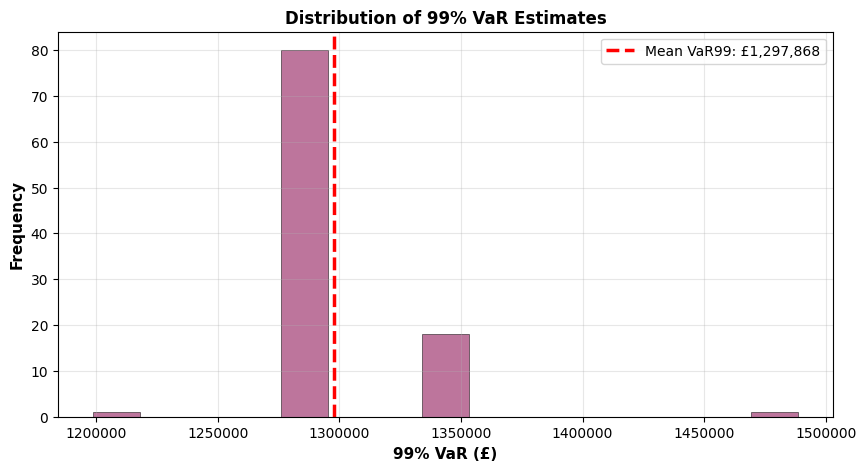

In [36]:
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(
    var_results,
    bins=15,
    color='#A23B72',        # same colour as your tail plot
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Mean VaR line
plt.axvline(
    np.mean(var_results),
    color='red',
    linestyle='--',
    linewidth=2.5,
    label=f"Mean VaR99: £{np.mean(var_results):,.0f}"
)

# Labels and title
plt.xlabel('99% VaR (£)', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Distribution of 99% VaR Estimates', fontsize=12, fontweight='bold')

# Grid + legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Prevent scientific notation on x‑axis
plt.ticklabel_format(style='plain', axis='x')

plt.show()


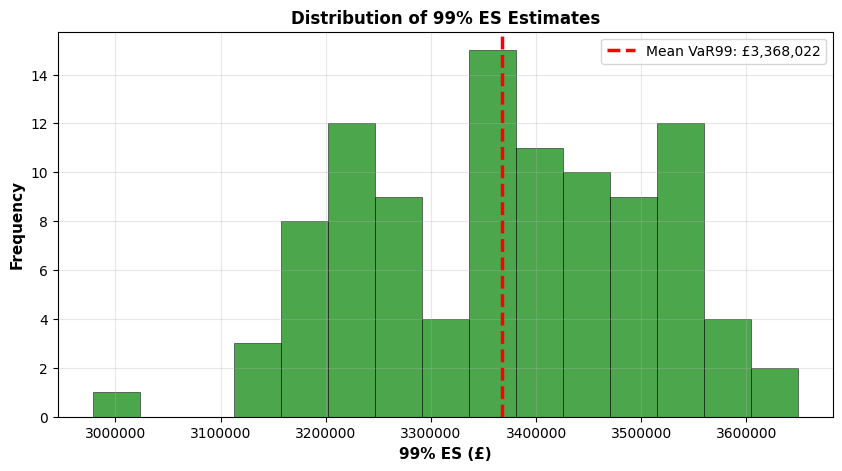

In [37]:
plt.figure(figsize=(10, 5))

# Histogram
plt.hist(
    es_results,
    bins=15,
    color='green',        
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Mean VaR line
plt.axvline(
    np.mean(es_results),
    color='red',
    linestyle='--',
    linewidth=2.5,
    label=f"Mean VaR99: £{np.mean(es_results):,.0f}"
)

# Labels and title
plt.xlabel('99% ES (£)', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Distribution of 99% ES Estimates', fontsize=12, fontweight='bold')

# Grid + legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Prevent scientific notation on x‑axis
plt.ticklabel_format(style='plain', axis='x')

plt.show()


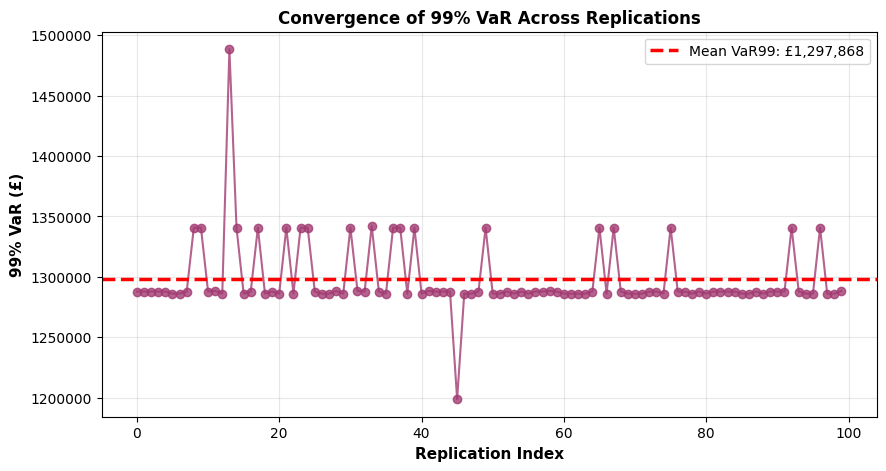

In [38]:
plt.figure(figsize=(10,5))

plt.plot(var_results, marker='o', color='#A23B72', alpha=0.8)
plt.axhline(np.mean(var_results), color='red', linestyle='--', linewidth=2.5,
            label=f"Mean VaR99: £{np.mean(var_results):,.0f}")

plt.title("Convergence of 99% VaR Across Replications", fontsize=12, fontweight='bold')
plt.xlabel("Replication Index", fontsize=11, fontweight='bold')
plt.ylabel("99% VaR (£)", fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ticklabel_format(style='plain', axis='y')

plt.show()


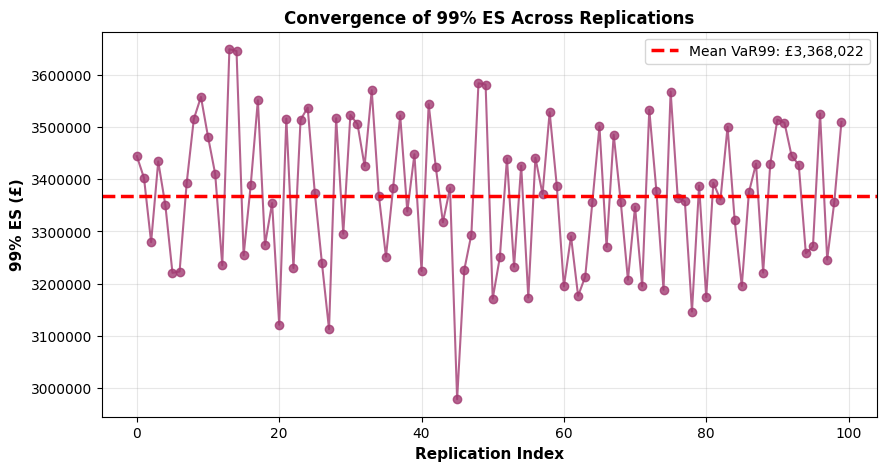

In [39]:
plt.figure(figsize=(10,5))

plt.plot(es_results, marker='o', color='#A23B72', alpha=0.8)
plt.axhline(np.mean(es_results), color='red', linestyle='--', linewidth=2.5,
            label=f"Mean VaR99: £{np.mean(es_results):,.0f}")

plt.title("Convergence of 99% ES Across Replications", fontsize=12, fontweight='bold')
plt.xlabel("Replication Index", fontsize=11, fontweight='bold')
plt.ylabel("99% ES (£)", fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

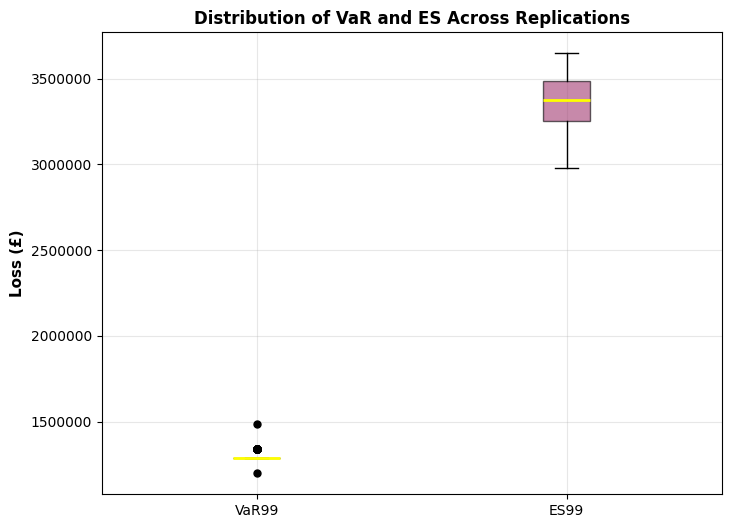

In [40]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [var_results, es_results],
    labels=['VaR99', 'ES99'],
    patch_artist=True,
    boxprops=dict(facecolor='#A23B72', alpha=0.6, color='black'),
    medianprops=dict(color='yellow', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='black')
)

plt.title("Distribution of VaR and ES Across Replications", fontsize=12, fontweight='bold')
plt.ylabel("Loss (£)", fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')

plt.show()
